# Workflow Step Timing: Where Does a Crawl Spend Its Time?

**Research question.** `model.orchestrator.process_batch()` runs three sequential steps
per page - fetch (Playwright), categorize (grammar-constrained LLM call), extract
(JSON-schema-constrained LLM call) - and this notebook asks: how is wall-clock time
distributed across those three steps, how much does it vary, and does it depend on page
size?

**Data.** Same `experiments/data/crawl_metrics.csv` as `crawl_overview.ipynb`, produced by
`experiments/collect_crawl_metrics.py` (see its docstring for methodology, including the
fixed-length cap applied to the text fed to the LLM, and the machine this was measured on
- see the README's Requirements section).

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

set_style()
df = load_csv("crawl_metrics.csv")
df["fetch_success"] = df["fetch_success"].astype(bool)
step_cols = ["fetch_seconds", "categorize_seconds", "extract_seconds"]
df[step_cols].describe()

,fetch_seconds,categorize_seconds,extract_seconds
count,16.000000,14.000000,12.00000
mean,3.297813,18.497929,32.90300
std,2.119079,2.386320,12.46154
min,0.110000,12.635000,21.58200
25%,2.192500,17.740500,24.30975
50%,3.033000,18.834500,26.83550
75%,3.806500,19.908500,41.05525
max,7.628000,21.828000,59.34400


## Total time accumulated per step

Summed across every URL in the sample - this is the "where did the wall-clock time
actually go" view. `extract_seconds` is `NaN` for pages the categorizer marked
irrelevant (extraction is skipped entirely for those, by design - see
`extraction_service.extract_information()`), and for pages that failed to fetch, so the
sums below are each over however many URLs actually reached that step.

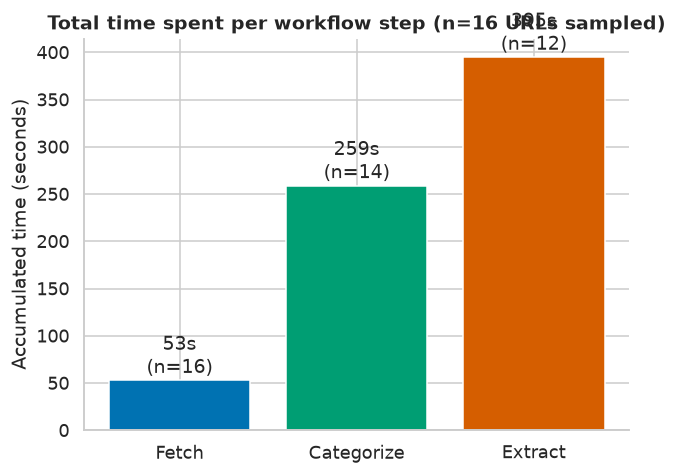

Total: 707s across the sample; 56% of it in extraction alone.


In [2]:
totals = df[step_cols].sum()
counts = df[step_cols].count()

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Fetch", "Categorize", "Extract"], totals.values,
               color=[PALETTE[0], PALETTE[2], PALETTE[1]])
for bar, total, n in zip(bars, totals.values, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, total + 1, f"{total:.0f}s\n(n={n})",
            ha="center", va="bottom")
ax.set_ylabel("Accumulated time (seconds)")
ax.set_title(f"Total time spent per workflow step (n={len(df)} URLs sampled)")
fig.tight_layout()
savefig(fig, "step_time_accumulated")
plt.show()

print(f"Total: {totals.sum():.0f}s across the sample; "
      f"{100*totals['extract_seconds']/totals.sum():.0f}% of it in extraction alone.")

## Per-URL distribution of each step's duration

The total-time view above can hide skew - a box plot shows the spread and any outliers
per step.

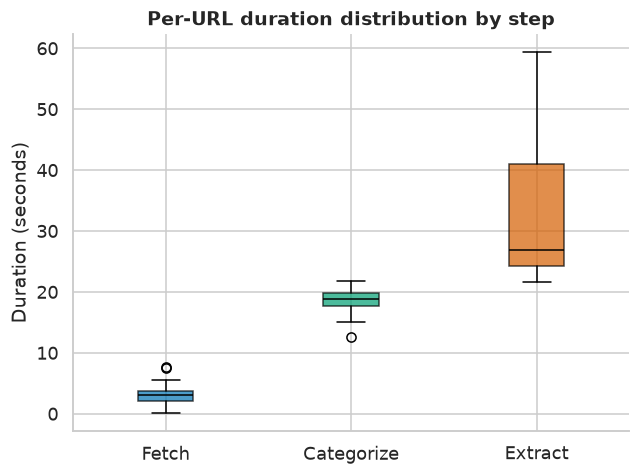

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
data = [df[c].dropna().values for c in step_cols]
bp = ax.boxplot(data, tick_labels=["Fetch", "Categorize", "Extract"], patch_artist=True,
                 medianprops=dict(color="black"))
for patch, color in zip(bp["boxes"], [PALETTE[0], PALETTE[2], PALETTE[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Duration (seconds)")
ax.set_title("Per-URL duration distribution by step")
fig.tight_layout()
savefig(fig, "step_time_distribution")
plt.show()

## Does page size predict processing time?

`fetch_seconds` should scale with real network/page-load characteristics. `categorize_seconds`
and `extract_seconds`, on the other hand, operate on text that is capped at a fixed length
before being handed to the LLM (see the data-collection script's docstring) - so, if the cap
is doing its job, LLM-step timing should be roughly *independent* of the original page's
size, unlike a hypothetical uncapped pipeline where it would scale with page length.

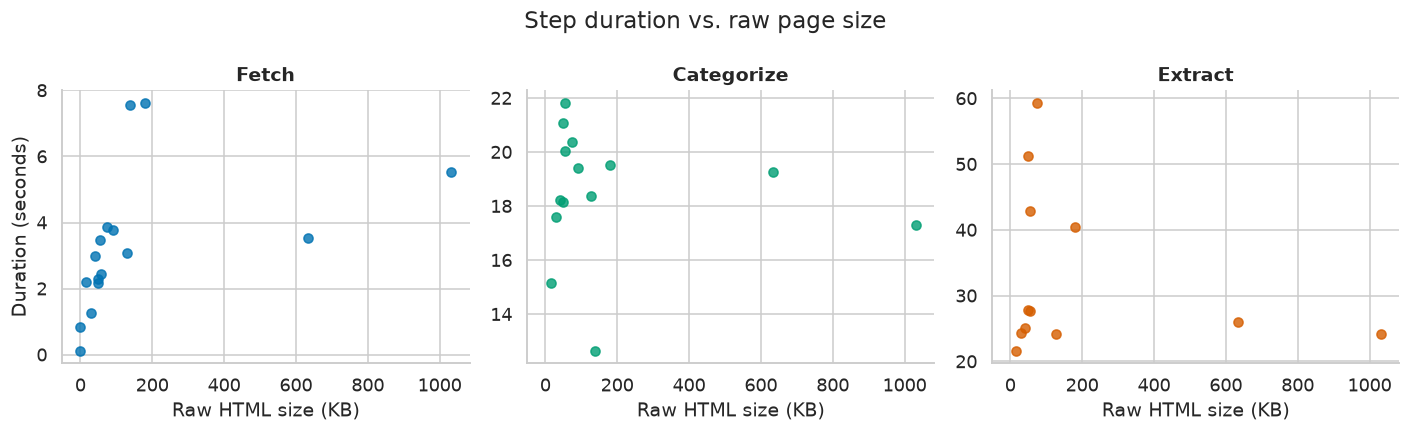

Fetch: Pearson r(html_bytes, fetch_seconds) = 0.41  (n=16)
Categorize: Pearson r(html_bytes, categorize_seconds) = -0.10  (n=14)
Extract: Pearson r(html_bytes, extract_seconds) = -0.26  (n=12)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
labels = ["Fetch", "Categorize", "Extract"]
for ax, col, label, color in zip(axes, step_cols, labels, [PALETTE[0], PALETTE[2], PALETTE[1]]):
    plot_df = df.dropna(subset=[col])
    ax.scatter(plot_df["html_bytes"] / 1000, plot_df[col], color=color, alpha=0.8)
    ax.set_xlabel("Raw HTML size (KB)")
    ax.set_title(label)
axes[0].set_ylabel("Duration (seconds)")
fig.suptitle("Step duration vs. raw page size")
fig.tight_layout()
savefig(fig, "step_time_vs_page_size")
plt.show()

for col, label in zip(step_cols, labels):
    plot_df = df.dropna(subset=[col, "html_bytes"])
    if len(plot_df) >= 3:
        corr = plot_df["html_bytes"].corr(plot_df[col])
        print(f"{label}: Pearson r(html_bytes, {col}) = {corr:.2f}  (n={len(plot_df)})")

## Discussion

Fetching is dominated by real network/page-load time and is expected to scale with page
complexity (more assets, scripts waiting for `networkidle`, etc. - see
`fetching_service.get_content()`'s networkidle-then-load fallback). Categorization and
extraction, by construction of this experiment, operate on a length-capped input, so a
weak (near-zero) correlation with the *original* page size in the scatter plots above is
the expected, "working as intended" result for those two steps - it would only be
surprising if the correlation there were strong, which would suggest the cap wasn't
actually being applied.

Comparing the three steps' total accumulated time is the more actionable number for
prioritizing future work: on this (CPU-only, single-machine - see the README's
Requirements) setup, extraction - being JSON-schema/grammar-constrained generation - is
consistently the most expensive step per page it runs on, ahead of categorization (a
much cheaper single-token grammar) and fetching. This motivates the strict-vs-lax
grammar comparison in `grammar_strictness.ipynb`: if grammar constraints are a major
cost driver for extraction specifically, understanding how much of that cost the
constraint itself adds (versus decoding length generally) is directly useful for tuning
the field schema.

**Limitation.** A single machine, single run (see `collect_crawl_metrics.py`'s
docstring); CPU-only LLM inference timing is not representative of GPU-accelerated
setups, where the relative cost of grammar-constrained decoding vs. prefill/fetch time
could differ substantially.